In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

## Частина 1. Підготовка даних

In [2]:
df = pd.read_csv('dowjones.csv')
df.head()

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df["Days"] = (df["Date"] - df["Date"].min()).dt.days
df.head()

,Date,Price,Days
0,1914-12-01,55.00,0
1,1915-01-01,56.55,31
2,1915-02-01,56.00,62
3,1915-03-01,58.30,90
4,1915-04-01,66.45,121


In [4]:
df.isna().sum()

Date     0
Price    0
Days     0
dtype: int64

In [5]:
X, y = df[['Days']], df['Price']
X_train, X_test_val, y_train, y_test_val = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=0.5, random_state=42)

print(X_train.shape, X_test.shape, X_val.shape)

(454, 1) (97, 1) (98, 1)


In [6]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std
X_val = (X_val - mean) / std

## Частина 2. Побудова дерева рішень

In [7]:
depths = [3, 5, 10]
models = {}
results = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    models[depth] = model
    
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    results.append({
        'Max Depth': depth,
        'Train R2': r2_score(y_train, y_train_pred),
        'Val R2': r2_score(y_val, y_val_pred),
        'Train MSE': mean_squared_error(y_train, y_train_pred),
        'Val MSE': mean_squared_error(y_val, y_val_pred),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Val MAE': mean_absolute_error(y_val, y_val_pred)
    })

results_df = pd.DataFrame(results)
print('Порівняння точності дерев рішення (Train vs Val):')
display(results_df)

Порівняння точності дерев рішення (Train vs Val):


,Max Depth,Train R2,Val R2,Train MSE,Val MSE,Train MAE,Val MAE
0,3,0.972828,0.958953,1772.181656,2745.133211,30.561778,35.170995
1,5,0.990603,0.983823,612.859510,1081.890591,17.528106,23.570298
2,10,0.999780,0.996531,14.341868,232.010009,2.038428,9.734531


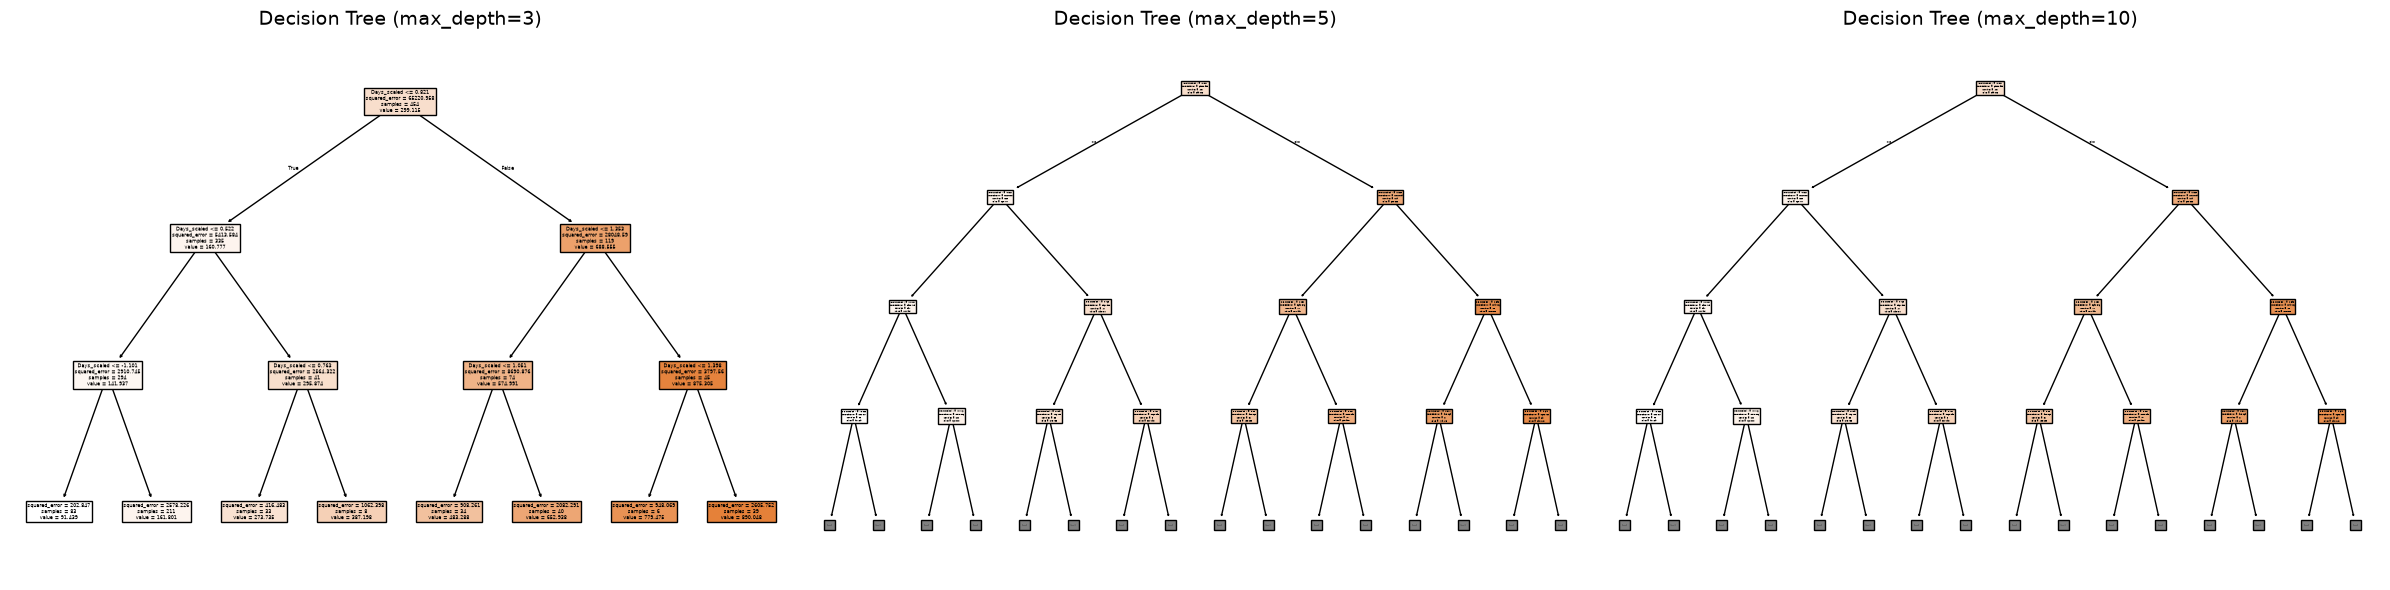

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for ax, depth in zip(axes, depths):
    plot_tree(models[depth], feature_names=['Days_scaled'], filled=True, ax=ax, max_depth=3)
    ax.set_title(f'Decision Tree (max_depth={depth})', fontsize=14)

plt.tight_layout()
plt.show()

Метрики на тестовому сеті:


,Max Depth,Test R2,Test MSE,Test RMSE,Test MAE
0,3,0.980016,1281.018110,35.791313,26.563601
1,5,0.988868,713.586832,26.713046,20.232062
2,10,0.998164,117.723664,10.850054,7.545023


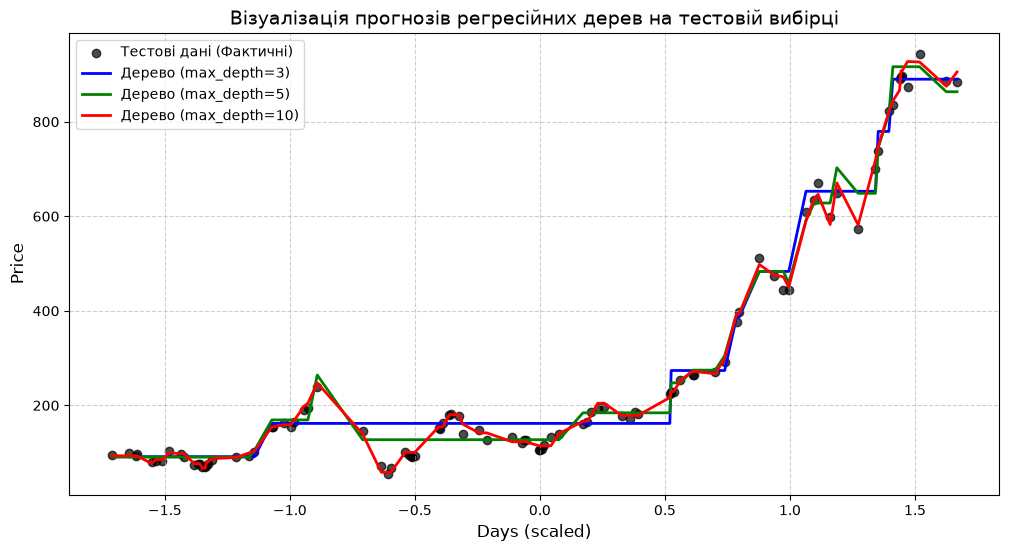

In [9]:
test_results = []
for depth in depths:
    y_test_pred = models[depth].predict(X_test)
    test_results.append({
        'Max Depth': depth,
        'Test R2': r2_score(y_test, y_test_pred),
        'Test MSE': mean_squared_error(y_test, y_test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Test MAE': mean_absolute_error(y_test, y_test_pred)
    })

test_results_df = pd.DataFrame(test_results)
print('Метрики на тестовому сеті:')
display(test_results_df)

plt.figure(figsize=(12, 6))
sort_idx = np.argsort(X_test['Days'].values)
X_test_sorted = X_test.iloc[sort_idx]
y_test_sorted = y_test.iloc[sort_idx]

plt.scatter(X_test['Days'], y_test, color='black', label='Тестові дані (Фактичні)', alpha=0.7)

colors = ['blue', 'green', 'red']
for depth, color in zip(depths, colors):
    y_test_pred = models[depth].predict(X_test_sorted)
    plt.plot(X_test_sorted['Days'], y_test_pred, color=color, label=f'Дерево (max_depth={depth})', linewidth=2)

plt.xlabel('Days (scaled)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Візуалізація прогнозів регресійних дерев на тестовій вибірці', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Частина 3. Побудова k-nn

In [10]:
k_values = [3, 7, 15]
knn_models = {}
knn_train_val_results = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_models[k] = knn
    
    y_tr_pred = knn.predict(X_train)
    y_val_pred = knn.predict(X_val)
    
    knn_train_val_results.append({
        'k (n_neighbors)': k,
        'Train R2': r2_score(y_train, y_tr_pred),
        'Val R2': r2_score(y_val, y_val_pred),
        'Train MSE': mean_squared_error(y_train, y_tr_pred),
        'Val MSE': mean_squared_error(y_val, y_val_pred),
        'Train MAE': mean_absolute_error(y_train, y_tr_pred),
        'Val MAE': mean_absolute_error(y_val, y_val_pred)
    })

knn_results_df = pd.DataFrame(knn_train_val_results)
print('Порівняння точності k-NN моделей (Train vs Val):')
display(knn_results_df)

Порівняння точності k-NN моделей (Train vs Val):


,k (n_neighbors),Train R2,Val R2,Train MSE,Val MSE,Train MAE,Val MAE
0,3,0.999176,0.996545,53.769286,231.086283,4.577151,8.721054
1,7,0.997999,0.995807,130.507634,280.410958,7.659522,10.472041
2,15,0.993474,0.992668,425.610750,490.336691,13.617731,15.515259


Метрики k-NN на тестовому сеті:


,k (n_neighbors),Test R2,Test MSE,Test RMSE,Test MAE
0,3,0.998358,105.237436,10.258530,6.706460
1,7,0.997081,187.139798,13.679905,8.787511
2,15,0.995020,319.251774,17.867618,12.329471


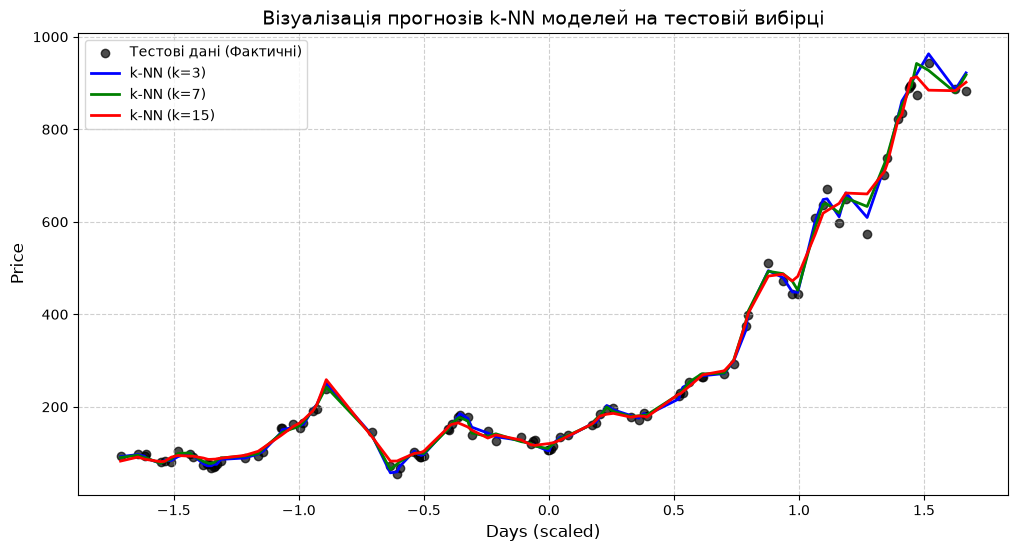

In [11]:
knn_test_results = []
for k in k_values:
    y_test_pred = knn_models[k].predict(X_test)
    knn_test_results.append({
        'k (n_neighbors)': k,
        'Test R2': r2_score(y_test, y_test_pred),
        'Test MSE': mean_squared_error(y_test, y_test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Test MAE': mean_absolute_error(y_test, y_test_pred)
    })

knn_test_results_df = pd.DataFrame(knn_test_results)
print('Метрики k-NN на тестовому сеті:')
display(knn_test_results_df)

plt.figure(figsize=(12, 6))
sort_idx = np.argsort(X_test['Days'].values)
X_test_sorted = X_test.iloc[sort_idx]

plt.scatter(X_test['Days'], y_test, color='black', label='Тестові дані (Фактичні)', alpha=0.7)

for k, color in zip(k_values, colors):
    y_test_pred = knn_models[k].predict(X_test_sorted)
    plt.plot(X_test_sorted['Days'], y_test_pred, color=color, label=f'k-NN (k={k})', linewidth=2)

plt.xlabel('Days (scaled)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Візуалізація прогнозів k-NN моделей на тестовій вибірці', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Частина 5. Побудова polynomial regression (для варіантів з регресією)

In [12]:
degrees = [2, 3, 5]
poly_models = {}
poly_train_val_results = []

for degree in degrees:
    model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())
    model.fit(X_train, y_train)
    poly_models[degree] = model
    
    y_tr_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    poly_train_val_results.append({
        'Degree': degree,
        'Train R2': r2_score(y_train, y_tr_pred),
        'Val R2': r2_score(y_val, y_val_pred),
        'Train MSE': mean_squared_error(y_train, y_tr_pred),
        'Val MSE': mean_squared_error(y_val, y_val_pred),
        'Train MAE': mean_absolute_error(y_train, y_tr_pred),
        'Val MAE': mean_absolute_error(y_val, y_val_pred)
    })

poly_results_df = pd.DataFrame(poly_train_val_results)
print('Порівняння точності поліноміальної регресії (Train vs Val):')
display(poly_results_df)

Порівняння точності поліноміальної регресії (Train vs Val):


,Degree,Train R2,Val R2,Train MSE,Val MSE,Train MAE,Val MAE
0,2,0.908153,0.908324,5990.318035,6131.105081,60.996749,56.123106
1,3,0.949734,0.940582,3278.388537,3973.748643,44.998074,44.204159
2,5,0.968631,0.958722,2045.893256,2760.551808,32.610343,35.096138


Метрики поліноміальної регресії на тестовому сеті:


,Degree,Test R2,Test MSE,Test RMSE,Test MAE
0,2,0.931546,4388.172312,66.243281,56.142212
1,3,0.960571,2527.525128,50.274498,41.131759
2,5,0.973542,1696.059773,41.183246,30.487229


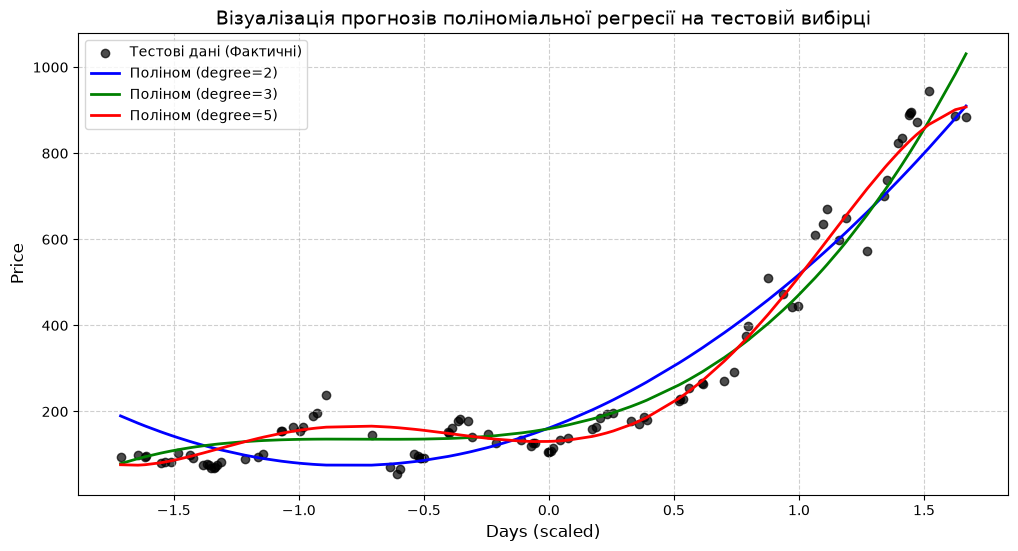

In [13]:
poly_test_results = []
for degree in degrees:
    y_test_pred = poly_models[degree].predict(X_test)
    poly_test_results.append({
        'Degree': degree,
        'Test R2': r2_score(y_test, y_test_pred),
        'Test MSE': mean_squared_error(y_test, y_test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Test MAE': mean_absolute_error(y_test, y_test_pred)
    })

poly_test_results_df = pd.DataFrame(poly_test_results)
print('Метрики поліноміальної регресії на тестовому сеті:')
display(poly_test_results_df)

plt.figure(figsize=(12, 6))
sort_idx = np.argsort(X_test['Days'].values)
X_test_sorted = X_test.iloc[sort_idx]

plt.scatter(X_test['Days'], y_test, color='black', label='Тестові дані (Фактичні)', alpha=0.7)

for degree, color in zip(degrees, colors):
    y_test_pred = poly_models[degree].predict(X_test_sorted)
    plt.plot(X_test_sorted['Days'], y_test_pred, color=color, label=f'Поліном (degree={degree})', linewidth=2)

plt.xlabel('Days (scaled)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Візуалізація прогнозів поліноміальної регресії на тестовій вибірці', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Частина 6. * Побудова випадкового лісу (random forest)

In [14]:
n_trees_list = [10, 50, 100]
rf_models = {}
rf_train_val_results = []

for n_trees in n_trees_list:
    model = RandomForestRegressor(n_estimators=n_trees, random_state=42)
    model.fit(X_train, y_train)
    rf_models[n_trees] = model
    
    y_tr_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    rf_train_val_results.append({
        'n_estimators': n_trees,
        'Train R2': r2_score(y_train, y_tr_pred),
        'Val R2': r2_score(y_val, y_val_pred),
        'Train MSE': mean_squared_error(y_train, y_tr_pred),
        'Val MSE': mean_squared_error(y_val, y_val_pred),
        'Train MAE': mean_absolute_error(y_train, y_tr_pred),
        'Val MAE': mean_absolute_error(y_val, y_val_pred)
    })

rf_results_df = pd.DataFrame(rf_train_val_results)
print('Порівняння точності випадкового лісу (Train vs Val):')
display(rf_results_df)

Порівняння точності випадкового лісу (Train vs Val):


,n_estimators,Train R2,Val R2,Train MSE,Val MSE,Train MAE,Val MAE
0,10,0.999608,0.996977,25.558797,202.157575,2.996830,8.318082
1,50,0.999739,0.996997,17.029568,200.831322,2.634233,8.479218
2,100,0.999762,0.997027,15.518277,198.799489,2.558045,8.420213


Метрики випадкового лісу на тестовому сеті:


,n_estimators,Test R2,Test MSE,Test RMSE,Test MAE
0,10,0.998623,88.271523,9.395293,6.087072
1,50,0.998498,96.270513,9.811754,6.108346
2,100,0.998457,98.892933,9.944493,6.121652


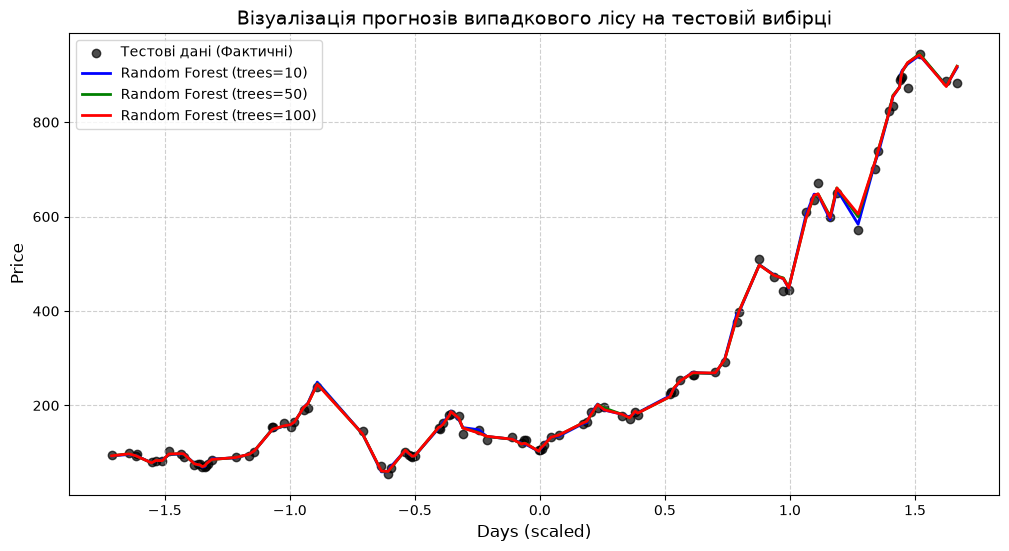

In [15]:
rf_test_results = []
for n_trees in n_trees_list:
    y_test_pred = rf_models[n_trees].predict(X_test)
    rf_test_results.append({
        'n_estimators': n_trees,
        'Test R2': r2_score(y_test, y_test_pred),
        'Test MSE': mean_squared_error(y_test, y_test_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Test MAE': mean_absolute_error(y_test, y_test_pred)
    })

rf_test_results_df = pd.DataFrame(rf_test_results)
print('Метрики випадкового лісу на тестовому сеті:')
display(rf_test_results_df)

plt.figure(figsize=(12, 6))
sort_idx = np.argsort(X_test['Days'].values)
X_test_sorted = X_test.iloc[sort_idx]

plt.scatter(X_test['Days'], y_test, color='black', label='Тестові дані (Фактичні)', alpha=0.7)

for n_trees, color in zip(n_trees_list, colors):
    y_test_pred = rf_models[n_trees].predict(X_test_sorted)
    plt.plot(X_test_sorted['Days'], y_test_pred, color=color, label=f'Random Forest (trees={n_trees})', linewidth=2)

plt.xlabel('Days (scaled)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Візуалізація прогнозів випадкового лісу на тестовій вибірці', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Частина 7. Кінцева валідація

Найкращі результати показав **Random Forest** з 10 або 50 деревами. Він отримав найменші значення RMSE (близько 9.40) та MAE (близько 6.09), оскільки поєднує прогнози багатьох дерев і зменшує кількість помилок.

**k-NN** (k = 3) та **Decision Tree** (max_depth = 10) також показали хороші результати (RMSE близько 10.26–10.85), але дерево рішень може легко перенавчатися, особливо якщо його не обмежувати.

Найгірше спрацювала **поліноміальна регресія**. Її RMSE становила від 41.18 до 66.24. Ймовірно, це пов'язано з тим, що зміни ціни мають складний характер, який важко описати одним поліномом.

## Як можна покращити результати

### Дерево рішень

* Спробувати різні значення `max_depth`.
* Налаштувати параметри `min_samples_split` і `min_samples_leaf`, щоб зменшити перенавчання.

### k-NN

* Перевірити різні значення `k`.
* Використати `weights='distance'`, щоб ближчі сусіди сильніше впливали на прогноз.

### Поліноміальна регресія

* Спробувати інший степінь полінома.
* Додати регуляризацію (`Ridge` або `Lasso`), щоб модель не перенавчалася.

### Random Forest

* Збільшити кількість дерев (`n_estimators`).
* Підібрати кращі параметри, наприклад `max_depth` або `max_features`.

### Загальні покращення

* Додати більше корисних ознак, якщо вони доступні.
* Використати крос-валідацію для точнішої оцінки якості моделей.
